# Controlled comparative statics for token demand

This notebook studies how token demand responds to token price $c$, token efficiency $\eta$, and model capability $m$. Every point re-solves the user's delegation horizon $s$, inference intensity $x$, and retry cap $k$.

The numerical design starts from one reference industry and changes one related parameter group at a time. A gray line denotes the reference case; each parameter group has one color, with a solid line for its high setting and a dashed line for its low setting. These are controlled comparative statics rather than estimates of named industries.

The primary figures maximize expected net surplus per scarce hour of human verification and use 100,000 human verification hours per case and period. The work-limited figures maximize surplus per unit of fixed work and allow adoption to respond. Both resource regimes are shown in token levels and indexed to the common scenario baseline. Both regimes use the same eleven cases. The single verification-burden group changes review overhead, variable review scale, and growth with delegated scope together.


## Setup

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from modeling_token_demand import (
    AttentionConstrainedOptimizer,
    IndustryModel,
    OptimizationSettings,
    PolicyOptimizer,
    REFERENCE_INDUSTRY,
    Scenario,
    illustrative_industries,
)

FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
ATTENTION_HOURS_PER_INDUSTRY = 100_000.0
work_limited_industries = illustrative_industries()
industries = tuple(
    replace(industry, human_attention_hours=ATTENTION_HOURS_PER_INDUSTRY)
    for industry in illustrative_industries()
)

## Controlled reference and parameter-group variations

For a candidate user action $(s,x,k)$—delegation horizon, tokens per work-hour in each attempt, and retry cap—the parameters enter the model through the following chain. First, the capability and execution equations are

$$
q_i(s;m)=\exp\left[-\left(\frac{s}{\lambda_i m}\right)^{\nu_i}\right],
\qquad
r_i(s,x;m,\eta)=\exp\left[-\frac{s}{a_i m[\eta(x/x_{\mathrm{ref}})]^{\alpha_i}}\right].
$$

Here $q_i$ is the share of tasks inside the capability frontier, while $r_i$ is the success probability of one attempt conditional on the task being solvable. The normalization $x_{\mathrm{ref}}$ only keeps the numerical units convenient. With at most $k$ attempts,

$$
P_i=q_i[1-(1-r_i)^k],
\qquad
E_i=(1-q_i)k+q_i\frac{1-(1-r_i)^k}{r_i},
$$

where $P_i$ is eventual success and $E_i$ is expected attempts. Human verification time and expected surplus per work-hour are

$$
h_i(s)=v[h_{0,i}+h_{1,i}s^{\beta_i}],
\qquad
u_i(s,x,k)=b_iP_i-E_i\left(cx+w_i\frac{h_i(s)}{s}\right).
$$

There are two different user problems. With a fixed amount of work, the user chooses $(s,x,k)$ to maximize $u_i$. With abundant useful work and scarce human attention, one chunk creates expected surplus $s u_i$ and consumes $E_i h_i(s)$ expected verification hours. The relevant objective is therefore

$$
J_i(s,x,k)=\frac{s u_i(s,x,k)}{E_i h_i(s)}
=\frac{s}{h_i(s)}\left[\frac{b_iP_i}{E_i}-cx\right]-w_i.
$$

The attention-constrained user chooses $(s_i^\star,x_i^\star,k_i^\star)=\arg\max J_i$. In the broader work-limited model, optimized per-work surplus instead determines adoption:

$$
A_i=\frac{1}{1+\exp[-(u_i^\star-\mu_i)/\sigma_i]},
$$

$$
D_i^{\mathrm{work}}=W_iA_ix_i^\star E_i^\star,
\qquad
D_i^{\mathrm{attention}}=H_i\frac{s_i^\star x_i^\star}{h_i(s_i^\star)}.
$$

The primary figures assume useful work is abundant and human attention is the binding resource, so they optimize $J_i$ and report $D_i=D_i^{\mathrm{attention}}$. The expected retry count cancels from demand because each retry consumes both another $sx$ tokens and another checkpoint $h_i(s)$. It does not cancel from $J_i$, because retrying changes expected value per verification hour. Adoption parameters and potential work volume therefore do not move the attention-constrained curves.

This makes the role of each parameter reasonably direct:

- $\lambda_i$ and $\nu_i$ shape the capability frontier $q_i$. A larger $\lambda_i$ supports longer tasks; $\nu_i$ controls how sharply feasibility falls near the frontier.
- $a_i$ and $\alpha_i$ shape conditional execution reliability $r_i$. A larger $a_i$ makes execution easier; $\alpha_i$ controls the diminishing return to additional inference.
- $h_{0,i}$, $h_{1,i}$, and $\beta_i$ determine human verification time. A $\beta_i$ near one means review grows almost proportionally with delegated scope.
- $b_i$ values successful work. The attention price $w_i$ determines whether operating is worthwhile but, because it enters $J_i$ as the constant $-w_i$, does not change the optimal policy in this strict binding-constraint case.
- $H_i$ is available human verification time and scales attention-limited demand proportionally.
- $\mu_i$, $\sigma_i$, and $W_i$ govern adoption and available work. They are inactive in the strictly attention-limited figures but active in the work-limited panels.

The scenario variables are common comparative-statics inputs rather than regime characteristics: model capability $m$, token efficiency $\eta$, token price $c$, and the verification-time multiplier $v$.

The controlled numerical experiment fixes $W_i$ and $H_i$ across cases because those endowments scale demand without identifying its shape. The reference is a transparent central case, not an estimated median industry. Each pair changes one related parameter group:

- high capability constraint lowers both $\lambda_i$ and $\nu_i$, tightening the frontier over the illustrated task sizes;
- high execution difficulty lowers both $a_i$ and $\alpha_i$, combining lower execution ease with weaker returns to extra inference;
- high verification burden raises $h_{0,i}$, $h_{1,i}$, and $\beta_i$ together, requiring more review that also grows faster with scope;
- high economic value raises $b_i$, with the attention cost $w_i=100$ fixed in every case; and
- high adoption hurdle raises both its location $\mu_i$ and dispersion $\sigma_i$.

High/low describes the named feature, not whether every numerical parameter or token demand is larger. Shape parameters are not globally ordered: capability and execution curves can cross outside the illustrated policy range, and dispersion alone does not uniformly raise adoption hurdles. The chosen adoption curves cross at surplus 75, below the surpluses in the adoption-pair comparison. The final audit checks technical ordering at plotted policies and adoption ordering at the surpluses in that comparison. These are combined group changes, not separate estimates of each parameter's effect.

The distinction between $b_i$ and $w_i$ matters in the work-limited problem: $b_i$ rewards successful work, while $w_i$ penalizes the human review it consumes. They need not move the chosen policy in the same way. In the attention-limited problem, $w_i$ is an additive constant, so it changes participation but not the policy conditional on operating. Holding it fixed keeps the economic-value comparison focused on $b_i$.


In [2]:
reference = REFERENCE_INDUSTRY
reference_symbols = (
    r"$\lambda$", r"$\nu$", "$a$", r"$\alpha$", "$h_0$", "$h_1$",
    r"$\beta$", "$b$", "$w$", r"$\mu$", r"$\sigma$", "$W$",
)
reference_header = (
    "| " + " | ".join(reference_symbols) + " |\n"
    + "|" + "---:|" * len(reference_symbols) + "\n"
)
reference_row = (
    f"| {reference.capability_horizon_hours:g} | "
    f"{reference.capability_shape:g} | {reference.execution_scale:g} | "
    f"{reference.inference_returns:g} | "
    f"{reference.verification_fixed_hours:g} | "
    f"{reference.verification_scale:g} | "
    f"{reference.verification_elasticity:g} | "
    f"{reference.value_per_work_hour:g} | "
    f"{reference.human_cost_per_hour:g} | "
    f"{reference.adoption_midpoint:g} | {reference.adoption_scale:g} | "
    f"{reference.potential_work_hours:,.0f} |"
)
display(Markdown("### Reference calibration\n\n" + reference_header + reference_row))

variation_groups = (
    ("Capability constraint", r"$(\lambda,\nu)$",
     ("capability_horizon_hours", "capability_shape")),
    ("Execution difficulty", r"$(a,\alpha)$",
     ("execution_scale", "inference_returns")),
    ("Verification burden", r"$(h_0,h_1,\beta)$",
     ("verification_fixed_hours", "verification_scale", "verification_elasticity")),
    ("Economic value", "$b$", ("value_per_work_hour",)),
    ("Adoption hurdle", r"$(\mu,\sigma)$", ("adoption_midpoint", "adoption_scale")),
)
comparison_by_name = {industry.name: industry for industry in work_limited_industries}


def parameter_values(industry, fields):
    values = [f"{getattr(industry, field):g}" for field in fields]
    return values[0] if len(values) == 1 else "(" + ", ".join(values) + ")"


variation_rows = []
for group, symbols, fields in variation_groups:
    settings_text = [
        parameter_values(comparison_by_name[name], fields)
        for name in (group + ": low", "Reference industry", group + ": high")
    ]
    variation_rows.append(f"| {group} | {symbols} | " + " | ".join(settings_text) + " |")
variation_header = (
    "| Parameter group | Parameters changed | Low setting | Reference | High setting |\n"
    "|---|---|---|---|---|\n"
)
display(Markdown("### Joint group variations\n\n" + variation_header + "\n".join(variation_rows)))
print("All eleven cases hold w = 100; both regimes use the same five high/low groups.")


### Reference calibration

| $\lambda$ | $\nu$ | $a$ | $\alpha$ | $h_0$ | $h_1$ | $\beta$ | $b$ | $w$ | $\mu$ | $\sigma$ | $W$ |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 12 | 1.25 | 4 | 0.5 | 0.03 | 0.05 | 0.5 | 125 | 100 | 107 | 8 | 1,000,000 |

### Joint group variations

| Parameter group | Parameters changed | Low setting | Reference | High setting |
|---|---|---|---|---|
| Capability constraint | $(\lambda,\nu)$ | (24, 1.5) | (12, 1.25) | (6, 1) |
| Execution difficulty | $(a,\alpha)$ | (8, 0.65) | (4, 0.5) | (2, 0.35) |
| Verification burden | $(h_0,h_1,\beta)$ | (0.015, 0.025, 0.25) | (0.03, 0.05, 0.5) | (0.06, 0.1, 0.95) |
| Economic value | $b$ | 100 | 125 | 150 |
| Adoption hurdle | $(\mu,\sigma)$ | (99, 6) | (107, 8) | (115, 10) |

All eleven cases hold w = 100; both regimes use the same five high/low groups.


## Numerical solution

Both optimizers enumerate every integer retry cap and, conditional on each $k$, search for the best $(s,x)$ in log space using a grid plus bounded multi-start local optimization. The primary optimizer maximizes $J_i$, while the comparison optimizer maximizes $u_i$. The action ranges below are intentionally wide.


In [3]:
settings = OptimizationSettings(
    min_delegation_hours=0.02,
    max_delegation_hours=80.0,
    min_tokens_per_work_hour=2_000.0,
    max_tokens_per_work_hour=20_000_000.0,
    max_attempts=12,
    grid_points_per_dimension=17,
    local_starts_per_attempt=4,
)
per_work_optimizer = PolicyOptimizer(settings)
attention_optimizer = AttentionConstrainedOptimizer(settings)
baseline = Scenario()

In [4]:
def solve_axis(
    policy_optimizer, scenario_field, values, industry_set=industries
):
    """Reoptimize every supplied parameter case along one scenario axis."""
    results = {}
    for industry in industry_set:
        model = IndustryModel(industry)
        results[industry.name] = [
            policy_optimizer.solve(
                model, replace(baseline, **{scenario_field: float(value)})
            )
            for value in values
        ]
    return results


PRICE_TICKS = (1, 2, 5, 10, 20, 40, 80)
TECHNOLOGY_TICKS = (0.35, 0.5, 1, 2, 3, 5)
GROUP_COLORS = {
    "Reference": "0.35",
    "Capability constraint": "#0072B2",
    "Execution difficulty": "#E69F00",
    "Verification burden": "#009E73",
    "Economic value": "#CC79A7",
    "Adoption hurdle": "#D55E00",
}


def variant_group_and_level(industry_name):
    """Return the controlled parameter group and high/low setting."""
    if industry_name == "Reference industry":
        return "Reference", "reference"
    group, level = industry_name.split(": ", maxsplit=1)
    return group, level


def variant_line_options(industry_name):
    """Use one color per parameter group and line style for high versus low."""
    group, level = variant_group_and_level(industry_name)
    if level == "reference":
        return {
            "color": GROUP_COLORS[group], "linestyle": "-", "linewidth": 2.8,
            "zorder": 10,
        }
    return {
        "color": GROUP_COLORS[group],
        "linestyle": "-" if level == "high" else "--",
        "linewidth": 1.8,
        "alpha": 0.95,
    }


def add_variant_legend(fig, ax, ncol=4, fontsize=8.4):
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="outside upper center", ncol=ncol,
        frameon=False, fontsize=fontsize,
    )


def label_log_x_axis(ax, ticks):
    """Show informative numeric labels instead of sparse powers of ten."""
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{tick:g}" for tick in ticks])


def baseline_index(values, baseline_value):
    matches = np.flatnonzero(np.isclose(values, baseline_value))
    if len(matches) != 1:
        raise ValueError(f"expected one baseline value {baseline_value}")
    return int(matches[0])


def indexed_series(values, quantities, baseline_value):
    """Index a positive series to one at the common scenario baseline."""
    quantities = np.asarray(quantities, dtype=float)
    denominator = quantities[baseline_index(values, baseline_value)]
    if denominator <= 0:
        raise ValueError("cannot index a series with a nonpositive baseline")
    return quantities / denominator


def attention_limited_tokens(outcome):
    """Return demand under abundant work and a binding attention constraint."""
    if outcome.attention_limited_tokens is None:
        raise ValueError("human_attention_hours must be set for these plots")
    return outcome.attention_limited_tokens


def plot_demand_panels(
    capabilities,
    capability_results,
    efficiencies,
    efficiency_results,
    prices,
    price_results,
    regime,
    normalize,
    filename,
):
    """Plot either resource regime in levels or within-case demand indexes."""
    regime_label, token_quantity = {
        "work": ("Work-limited", lambda outcome: outcome.work_limited_tokens),
        "attention": ("Attention-limited", attention_limited_tokens),
    }[regime]
    panels = (
        (
            capabilities, capability_results, "(a) Model capability",
            "Model capability, $m$", TECHNOLOGY_TICKS, 1.0, False,
        ),
        (
            efficiencies, efficiency_results, "(b) Token efficiency",
            r"Token efficiency, $\eta$", TECHNOLOGY_TICKS, 1.0, False,
        ),
        (
            prices, price_results, "(c) Token price",
            "Token price, $ per million (lower cost to the right)",
            PRICE_TICKS, 10.0, True,
        ),
    )
    fig, axes = plt.subplots(1, 3, figsize=(16.0, 6.2), sharey=True)
    for ax, panel in zip(axes, panels):
        values, results, title, xlabel, ticks, baseline_value, reverse_x = panel
        for industry_name, outcomes in results.items():
            demand = np.array([
                token_quantity(outcome) for outcome in outcomes
            ])
            if normalize:
                demand = indexed_series(values, demand, baseline_value)
            else:
                demand = demand / 1e9
            ax.plot(
                values, demand, label=industry_name,
                **variant_line_options(industry_name),
            )
        ax.set_xscale("log")
        ax.set_yscale("log")
        label_log_x_axis(ax, ticks)
        ax.axvline(
            baseline_value, color="0.55", linestyle=":", linewidth=1.1
        )
        if normalize:
            ax.axhline(1.0, color="0.72", linestyle=":", linewidth=0.9)
        if reverse_x:
            ax.invert_xaxis()
        ax.set_title(title, loc="left")
        ax.set_xlabel(xlabel)
        ax.grid(which="major", alpha=0.25)
        ax.grid(which="minor", alpha=0.08)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.99),
        ncol=4, frameon=False, fontsize=8.2,
    )
    fig.subplots_adjust(
        left=0.07, right=0.99, bottom=0.13, top=0.77, wspace=0.03
    )
    if normalize:
        fig.supylabel(f"{regime_label} token demand index (scenario baseline = 1)")
    else:
        fig.supylabel(f"{regime_label} token demand (billions per period)")
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig


def plot_demand(
    values, results, xlabel, filename, baseline_value, xticks, reverse_x=False
):
    """Plot indexed attention demand for the controlled parameter cases."""
    fig, ax = plt.subplots(figsize=(11.0, 7.0), constrained_layout=True)
    for industry_name, outcomes in results.items():
        demand = indexed_series(
            values,
            [attention_limited_tokens(outcome) for outcome in outcomes],
            baseline_value,
        )
        ax.plot(
            values, demand, label=industry_name,
            **variant_line_options(industry_name),
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(baseline_value, color="0.55", linestyle=":", linewidth=1.1)
    ax.axhline(1.0, color="0.72", linestyle=":", linewidth=0.9)
    if reverse_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Attention-limited token demand index (baseline = 1)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    add_variant_legend(fig, ax)
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig


def plot_capability_objective_comparison(
    capabilities, attention_results, per_work_results, filename
):
    """Compare the two objectives for the reference industry."""
    name = "Reference industry"
    attention_demand = indexed_series(
        capabilities,
        [attention_limited_tokens(outcome) for outcome in attention_results[name]],
        1.0,
    )
    per_work_demand = indexed_series(
        capabilities,
        [attention_limited_tokens(outcome) for outcome in per_work_results[name]],
        1.0,
    )
    fig, ax = plt.subplots(figsize=(10.0, 6.2), constrained_layout=True)
    ax.plot(
        capabilities, attention_demand, color="#0072B2", linewidth=2.3,
        label="Optimize per attention-hour",
    )
    ax.plot(
        capabilities, per_work_demand, color="0.35", linestyle="--",
        linewidth=2.1, label="Optimize per work-hour, then cap",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    label_log_x_axis(ax, TECHNOLOGY_TICKS)
    ax.axvline(1.0, color="0.55", linestyle=":", linewidth=1.0)
    ax.axhline(1.0, color="0.72", linestyle=":", linewidth=0.9)
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.08)
    ax.set_xlabel("Model capability, $m$")
    ax.set_ylabel("Attention-limited token demand index ($m=1$ = 1)")
    ax.legend(frameon=False)
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig


def plot_token_spend(values, results, filename, xticks):
    """Plot indexed token spending as token price changes."""
    fig, ax = plt.subplots(figsize=(11.0, 7.0), constrained_layout=True)
    for industry_name, outcomes in results.items():
        spend = indexed_series(
            values,
            [
                attention_limited_tokens(outcome) * price_per_million
                for outcome, price_per_million in zip(outcomes, values)
            ],
            10.0,
        )
        ax.plot(
            values, spend, label=industry_name,
            **variant_line_options(industry_name),
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(10.0, color="0.55", linestyle=":", linewidth=1.1)
    ax.axhline(1.0, color="0.72", linestyle=":", linewidth=0.9)
    ax.invert_xaxis()
    ax.set_xlabel("Token price, $ per million tokens (lower cost to the right)")
    ax.set_ylabel("Attention-limited token spend index (baseline = 1)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    add_variant_legend(fig, ax)
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig


def plot_surplus_by_capability(capabilities, results, filename, xticks):
    """Plot indexed optimized per-work surplus as capability changes."""
    fig, ax = plt.subplots(figsize=(11.0, 7.0), constrained_layout=True)
    for industry_name, outcomes in results.items():
        surplus = indexed_series(
            capabilities,
            [outcome.surplus_per_work_hour for outcome in outcomes],
            1.0,
        )
        ax.plot(
            capabilities, surplus, label=industry_name,
            **variant_line_options(industry_name),
        )

    ax.set_xscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(1.0, color="0.55", linestyle=":", linewidth=1.1)
    ax.axhline(1.0, color="0.72", linestyle=":", linewidth=0.9)
    ax.set_xlabel("Model capability, $m$")
    ax.set_ylabel("Optimized per-work surplus index ($m=1$ = 1)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    add_variant_legend(fig, ax)
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig


def print_retry_switches(values, results):
    """Describe the discrete choices behind visible demand kinks."""
    for industry_name, outcomes in results.items():
        retries = np.array([outcome.policy.max_attempts for outcome in outcomes])
        switches = np.flatnonzero(retries[1:] != retries[:-1]) + 1
        if len(switches):
            descriptions = [
                f"{values[j - 1]:.3g} to {values[j]:.3g}: "
                f"k {retries[j - 1]} to {retries[j]}"
                for j in switches
            ]
            print(f"{industry_name}: " + "; ".join(descriptions))


def plot_attention_shadow_price(capabilities, results, filename):
    """Plot indexed shadow value and its exact capability elasticity."""
    fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.5), constrained_layout=True)
    level_ax, elasticity_ax = axes
    industries_by_name = {industry.name: industry for industry in industries}

    for industry_name, outcomes in results.items():
        industry = industries_by_name[industry_name]
        shadow_prices = indexed_series(
            capabilities,
            [
                outcome.surplus_per_attention_hour + industry.human_cost_per_hour
                for outcome in outcomes
            ],
            1.0,
        )
        elasticities = []
        for outcome in outcomes:
            s = outcome.policy.delegation_hours
            variable_review = (
                industry.verification_scale
                * s ** industry.verification_elasticity
            )
            theta = (
                industry.verification_elasticity * variable_review
                / (industry.verification_fixed_hours + variable_review)
            )
            elasticities.append(1.0 - theta)

        plot_options = variant_line_options(industry_name)
        level_ax.plot(
            capabilities, shadow_prices, label=industry_name, **plot_options
        )
        elasticity_ax.plot(capabilities, elasticities, **plot_options)

    for ax in axes:
        ax.set_xscale("log")
        label_log_x_axis(ax, TECHNOLOGY_TICKS)
        ax.axvline(1.0, color="0.55", linestyle=":", linewidth=1.1)
        ax.grid(which="major", alpha=0.25)
        ax.grid(which="minor", alpha=0.08)
        ax.set_xlabel("Model capability, $m$")

    level_ax.set_yscale("log")
    level_ax.axhline(1.0, color="0.72", linestyle=":", linewidth=0.9)
    level_ax.set_ylabel("Shadow price index ($m=1$ = 1)")
    elasticity_ax.set_ylim(0.0, 1.02)
    elasticity_ax.set_ylabel(
        r"Exact elasticity, $d\log \rho^\star / d\log m$"
    )
    add_variant_legend(fig, level_ax, ncol=4, fontsize=8.1)
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig


### Baseline attention-constrained policies

The following table reports levels at the common scenario baseline before the plotted curves are indexed.


In [5]:
baseline_rows = []
for industry in industries:
    outcome = attention_optimizer.solve(IndustryModel(industry), baseline)
    baseline_rows.append(
        f"| {industry.name} | {outcome.policy.delegation_hours:.3f} | "
        f"{outcome.policy.tokens_per_work_hour:,.0f} | {outcome.policy.max_attempts} | "
        f"{outcome.eventual_success:.1%} | "
        f"{outcome.surplus_per_attention_hour:,.0f} | "
        f"{attention_limited_tokens(outcome) / 1e9:.1f} |"
    )
baseline_header = (
    "| Parameter case | s* (hours) | x* (tokens/hour) | k* | Success | Surplus/attention-hour | Attention demand (billions) |\n"
    "|---|---:|---:|---:|---:|---:|---:|\n"
)
display(Markdown(baseline_header + "\n".join(baseline_rows)))

| Parameter case | s* (hours) | x* (tokens/hour) | k* | Success | Surplus/attention-hour | Attention demand (billions) |
|---|---:|---:|---:|---:|---:|---:|
| Reference industry | 3.491 | 1,041,581 | 1 | 61.6% | 1,784 | 2946.2 |
| Capability constraint: high | 2.223 | 724,685 | 1 | 56.2% | 1,239 | 1541.0 |
| Capability constraint: low | 5.191 | 1,389,234 | 1 | 63.8% | 2,277 | 5010.7 |
| Execution difficulty: high | 1.959 | 1,094,175 | 1 | 59.0% | 1,130 | 2143.7 |
| Execution difficulty: low | 4.744 | 788,160 | 1 | 62.6% | 2,303 | 2691.7 |
| Verification burden: high | 1.765 | 772,824 | 1 | 77.9% | 583 | 589.1 |
| Verification burden: low | 4.407 | 1,114,199 | 1 | 54.0% | 4,750 | 9585.5 |
| Economic value: high | 3.614 | 1,204,143 | 1 | 61.7% | 2,225 | 3479.9 |
| Economic value: low | 3.339 | 870,807 | 1 | 61.6% | 1,354 | 2395.6 |
| Adoption hurdle: high | 3.491 | 1,041,581 | 1 | 61.6% | 1,784 | 2946.2 |
| Adoption hurdle: low | 3.491 | 1,041,581 | 1 | 61.6% | 1,784 | 2946.2 |

## Token price

The horizontal axis is reversed, so moving right means tokens become cheaper. The dotted vertical line is the baseline price. Every point reoptimizes the interaction policy.


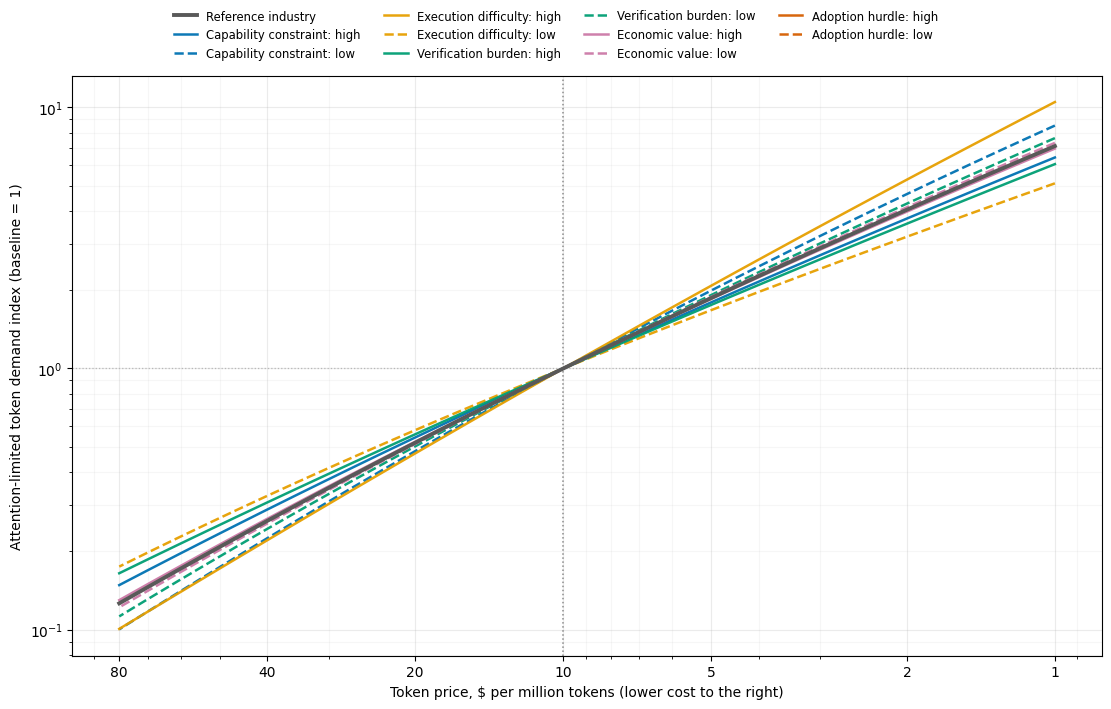

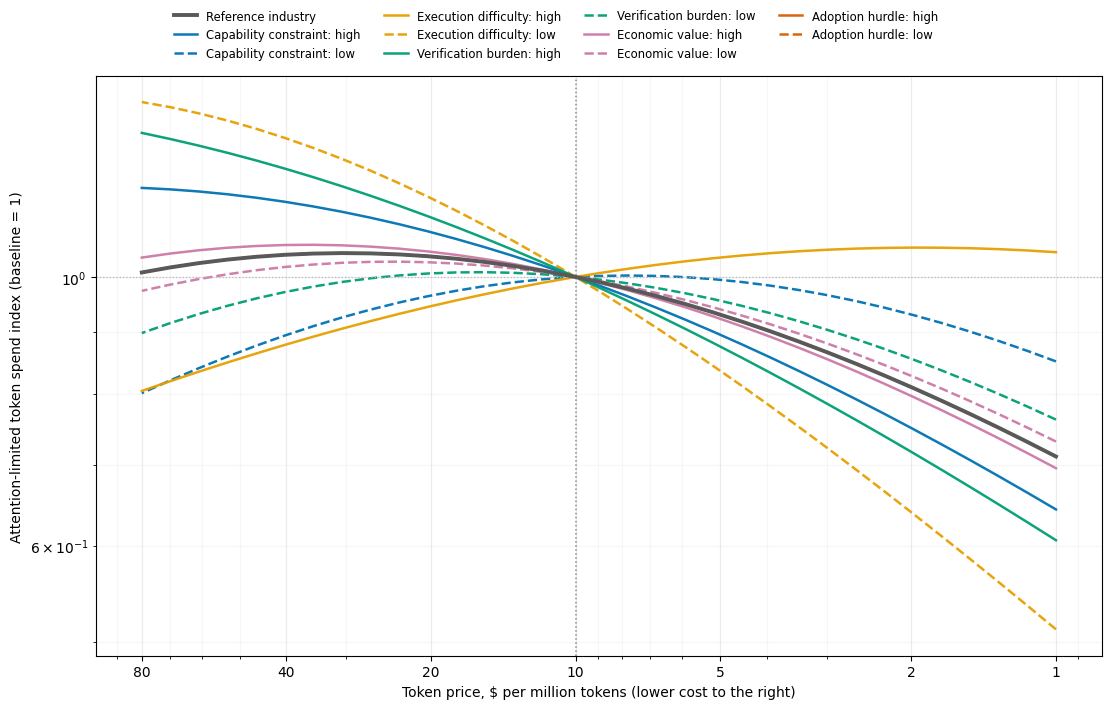

In [6]:
token_prices = np.unique(np.append(np.geomspace(1.0, 80.0, 33), 10.0))
price_results = solve_axis(
    attention_optimizer, "token_price_per_million", token_prices
)
work_limited_price_results = solve_axis(
    per_work_optimizer,
    "token_price_per_million",
    token_prices,
    industry_set=work_limited_industries,
)
print_retry_switches(token_prices, price_results)
price_figure = plot_demand(
    token_prices,
    price_results,
    xlabel="Token price, $ per million tokens (lower cost to the right)",
    filename="token-demand-vs-price.png",
    baseline_value=10.0,
    xticks=PRICE_TICKS,
    reverse_x=True,
)
spend_figure = plot_token_spend(
    token_prices, price_results, filename="token-spend-vs-price.png",
    xticks=PRICE_TICKS,
)

Cheaper tokens increase attention-limited demand because users choose greater inference intensity for each unit of work launched by a scarce human checkpoint. This is a quantity response to price. The efficiency experiment below asks the separate Jevons-style question: can making every token more effective increase total token use?

The second price figure reports the corresponding spending index $cD(c)$. Moving right while a spending curve rises means demand increased more than proportionally to the price decline. The controlled cases reveal which parameter group changes that elasticity without confounding it with unrelated industry differences.


## Token efficiency

Higher $\eta$ means each token buys more effective inference while model capability $m$ is held fixed. Thus this experiment isolates efficiency from an outward shift in the capability frontier.

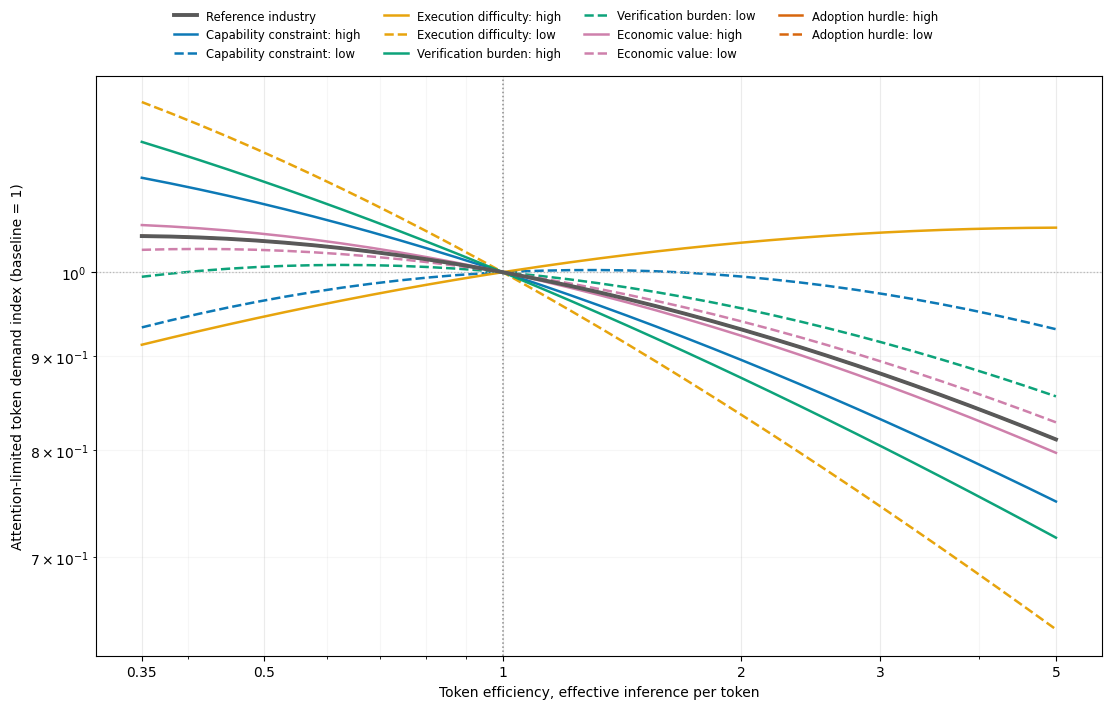

In [7]:
token_efficiencies = np.unique(np.append(np.geomspace(0.35, 5.0, 33), 1.0))
efficiency_results = solve_axis(
    attention_optimizer, "token_efficiency", token_efficiencies
)
work_limited_efficiency_results = solve_axis(
    per_work_optimizer,
    "token_efficiency",
    token_efficiencies,
    industry_set=work_limited_industries,
)
print_retry_switches(token_efficiencies, efficiency_results)
efficiency_figure = plot_demand(
    token_efficiencies,
    efficiency_results,
    xlabel="Token efficiency, effective inference per token",
    filename="token-demand-vs-efficiency.png",
    baseline_value=1.0,
    xticks=TECHNOLOGY_TICKS,
)

In the attention-limited regime, efficiency affects demand through two opposing choices. It lowers the tokens needed for a given effective inference level, but it may let each scarce human checkpoint launch a larger delegated chunk. Jevons-style growth occurs only if the increase in supervisory leverage $s_i^\star/h_i(s_i^\star)$ outweighs the decline in chosen token intensity $x_i^\star$.

Because every case differs from the reference in only one parameter group, departures from the gray line can now be attributed to that group. Cases that are inactive under the attention constraint, such as the adoption hurdle, coincide with the reference curve by construction.


## Model capability

Model capability directly expands the share of tasks inside the capability frontier:

$$
q_i(s;m)=\exp\left[-\left(\frac{s}{\lambda_i m}\right)^{\nu_i}\right],
\qquad
\frac{\partial q_i}{\partial m}
=\frac{q_i\nu_i}{m}\left(\frac{s}{\lambda_i m}\right)^{\nu_i}>0.
$$

Holding the task horizon $s$ fixed, $q_i$ therefore rises monotonically toward one as $m$ increases. The effect is largest when a parameter regime is near its capability frontier; once $q_i$ is already near one, this direct channel becomes small.

The plotted response is broader than this derivative. In the model, larger $m$ also raises conditional execution reliability $r_i$, and the attention-constrained user reoptimizes $s$, $x$, and $k$ to maximize $J_i$. Demand is then $H_i s_i^\star x_i^\star/h_i(s_i^\star)$. A line rises when capability expands work launched per checkpoint faster than chosen token intensity falls. The comparison figure also shows what happens under the old sequence: maximize per-work surplus $u_i$ first and only then apply the attention cap.

### Shadow price of scarce attention

It is useful to remove the separately specified attention charge and derive the value of the attention constraint itself. Define gross value per attention hour, after token spending but before any exogenous wage charge, as

$$
R_i(s,x,k;m)
=\frac{s}{h_i(s)}
\left[\frac{b_iP_i(s,x,k;m)}{E_i(s,x,k;m)}-cx\right].
$$

With abundant interchangeable work and a binding attention endowment $H_i$, the multiplier on $N_iE_ih_i(s)\leq H_i$ is

$$
\rho_i^\star(m)
=\max\left\{0,\max_{s,x,k}R_i(s,x,k;m)\right\}.
$$

This is the marginal optimized value of one additional human attention hour. The existing `AttentionConstrainedOptimizer` maximizes $J_i=R_i-w_i$. Since $w_i$ is constant, it already selects the same policy; its reported objective plus $w_i$ gives $\rho_i^\star$. If $w_i$ is instead a real wage paid in addition to the scarce endowment, $J_i^\star=\rho_i^\star-w_i$ is the scarcity rent after that wage.

The capability dependence can be characterized exactly. Because $k=1$ is optimal here, write

$$
A_i=\left(\frac{s}{\lambda_i m}\right)^{\nu_i},
\qquad
B_i=\frac{s}{a_i m[\eta(x/x_{\mathrm{ref}})]^{\alpha_i}},
\qquad
\theta_i(s)=\frac{s h_i'(s)}{h_i(s)}.
$$

The two interior first-order conditions are

$$
cx=\alpha_iB_i b_i e^{-A_i-B_i},
\qquad
\nu_iA_i+B_i=[1-\theta_i(s)](1-\alpha_iB_i).
$$

They reduce the two-dimensional continuous problem to one strictly increasing scalar equation. Set

$$
B_i(s,m)=
\frac{1-\theta_i(s)-\nu_iA_i(s,m)}
     {1+\alpha_i[1-\theta_i(s)]}.
$$

Then $s_i^\star$ is the unique positive root, before any imposed numerical action bounds, of

$$
\alpha_i\log\!\left(\frac{c x_{\mathrm{ref}}}{\alpha_i b_i\eta}\right)
+\log\!\left(\frac{s}{a_i m}\right)
+\alpha_iA_i-(\alpha_i+1)\log B_i+\alpha_iB_i=0,
$$

and

$$
x_i^\star=\frac{x_{\mathrm{ref}}}{\eta}
\left(\frac{s_i^\star}{a_i mB_i}\right)^{1/\alpha_i},
\qquad
\rho_i^\star=
\frac{s_i^\star}{h_i(s_i^\star)}
 b_i e^{-A_i-B_i}(1-\alpha_iB_i).
$$

For the calibrated form $h_i(s)=h_{0,i}+h_{1,i}s^{\beta_i}$ with $h_{0,i}>0$ and $0\leq\beta_i\leq1$, the envelope theorem gives the especially simple exact slope

$$
\boxed{
\frac{d\log\rho_i^\star}{d\log m}
=1-\theta_i(s_i^\star)
=1-\frac{\beta_i h_{1,i}(s_i^\star)^{\beta_i}}
{h_{0,i}+h_{1,i}(s_i^\star)^{\beta_i}}
}.
$$

Thus capability strictly raises the shadow price in these calibrations. Its elasticity lies between $1-\beta_i$ and $1$: capability is most valuable where verification grows slowly with task scope. There is generally no elementary closed form for $s_i^\star(m)$ because fixed and variable verification interact, but the boxed derivative and the scalar characterization are exact; the root below is solved to numerical tolerance rather than with a multidimensional local search.


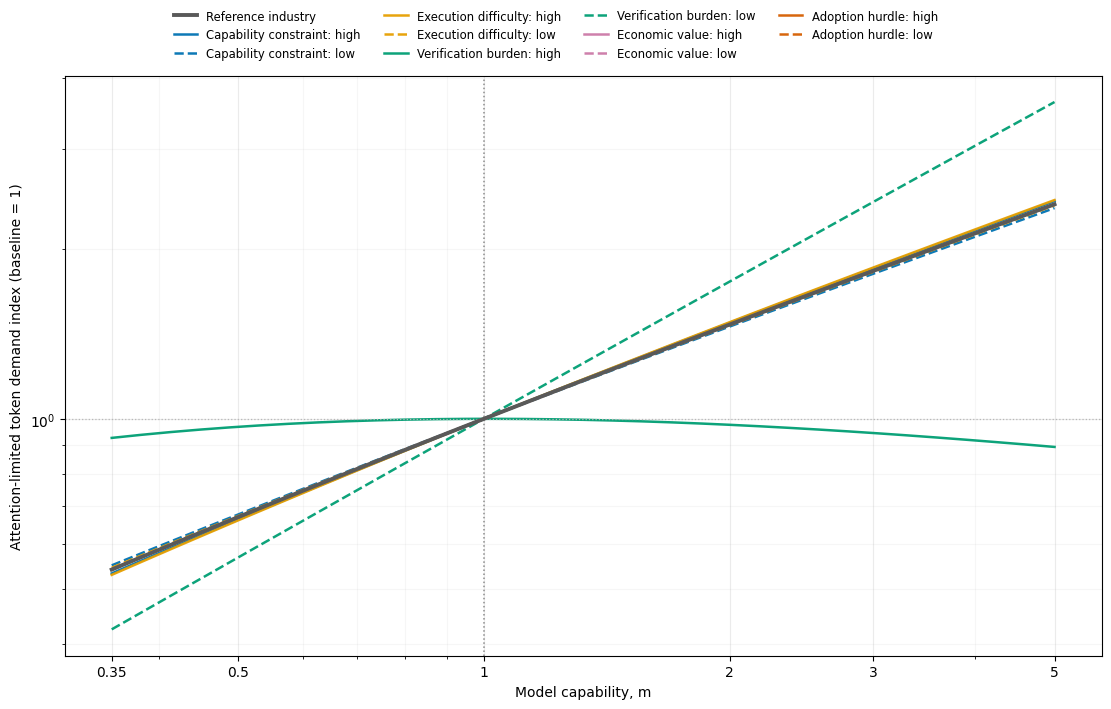

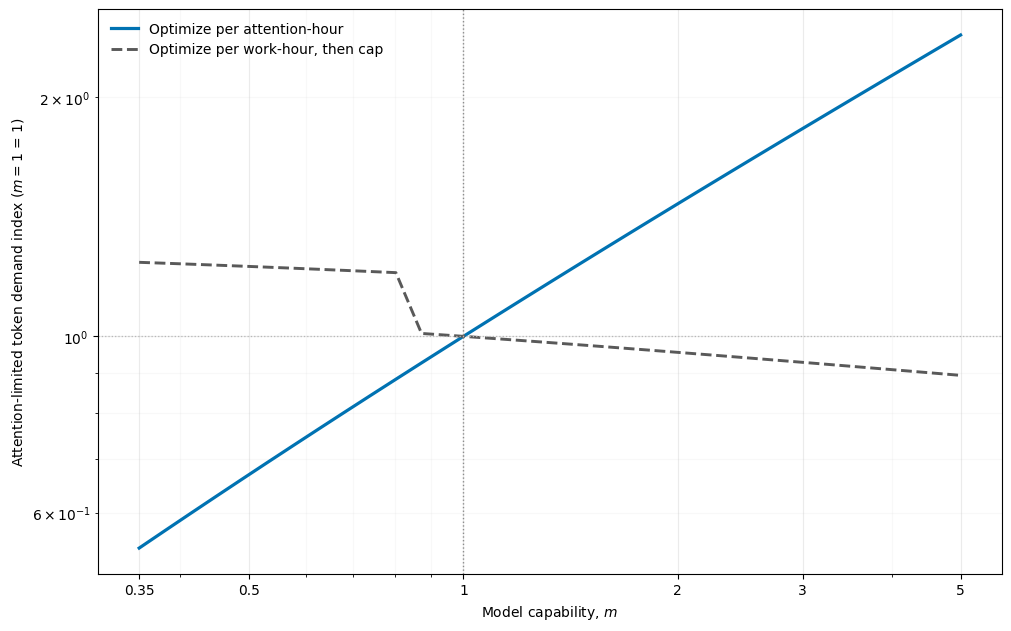

In [8]:
model_capabilities = np.unique(np.append(np.geomspace(0.35, 5.0, 33), 1.0))
attention_capability_results = solve_axis(
    attention_optimizer, "model_capability", model_capabilities
)
per_work_capability_results = solve_axis(
    per_work_optimizer, "model_capability", model_capabilities,
    industry_set=tuple(
        replace(industry, human_attention_hours=ATTENTION_HOURS_PER_INDUSTRY)
        for industry in work_limited_industries
    ),
)
work_limited_capability_results = solve_axis(
    per_work_optimizer,
    "model_capability",
    model_capabilities,
    industry_set=work_limited_industries,
)
print_retry_switches(model_capabilities, attention_capability_results)
capability_figure = plot_demand(
    model_capabilities,
    attention_capability_results,
    xlabel="Model capability, m",
    filename="token-demand-vs-capability.png",
    baseline_value=1.0,
    xticks=TECHNOLOGY_TICKS,
)
capability_comparison_figure = plot_capability_objective_comparison(
    model_capabilities,
    attention_capability_results,
    per_work_capability_results,
    filename="token-demand-vs-capability-objectives.png",
)

Largest relative difference between general and scalar solutions: 3.78e-13


| Parameter case | $\rho^*(0.35)$ | $\rho^*(1)$ | $\rho^*(5)$ | Elasticity at $m=1$ |
|---|---:|---:|---:|---:|
| Reference industry | 956 | 1,884 | 4,879 | 0.622 |
| Capability constraint: high | 663 | 1,339 | 3,569 | 0.643 |
| Capability constraint: low | 1,231 | 2,377 | 6,019 | 0.604 |
| Execution difficulty: high | 604 | 1,230 | 3,310 | 0.650 |
| Execution difficulty: low | 1,239 | 2,403 | 6,114 | 0.608 |
| Verification burden: high | 468 | 683 | 978 | 0.296 |
| Verification burden: low | 2,029 | 4,850 | 17,963 | 0.823 |
| Economic value: high | 1,182 | 2,325 | 6,008 | 0.620 |
| Economic value: low | 736 | 1,454 | 3,776 | 0.624 |
| Adoption hurdle: high | 956 | 1,884 | 4,879 | 0.622 |
| Adoption hurdle: low | 956 | 1,884 | 4,879 | 0.622 |

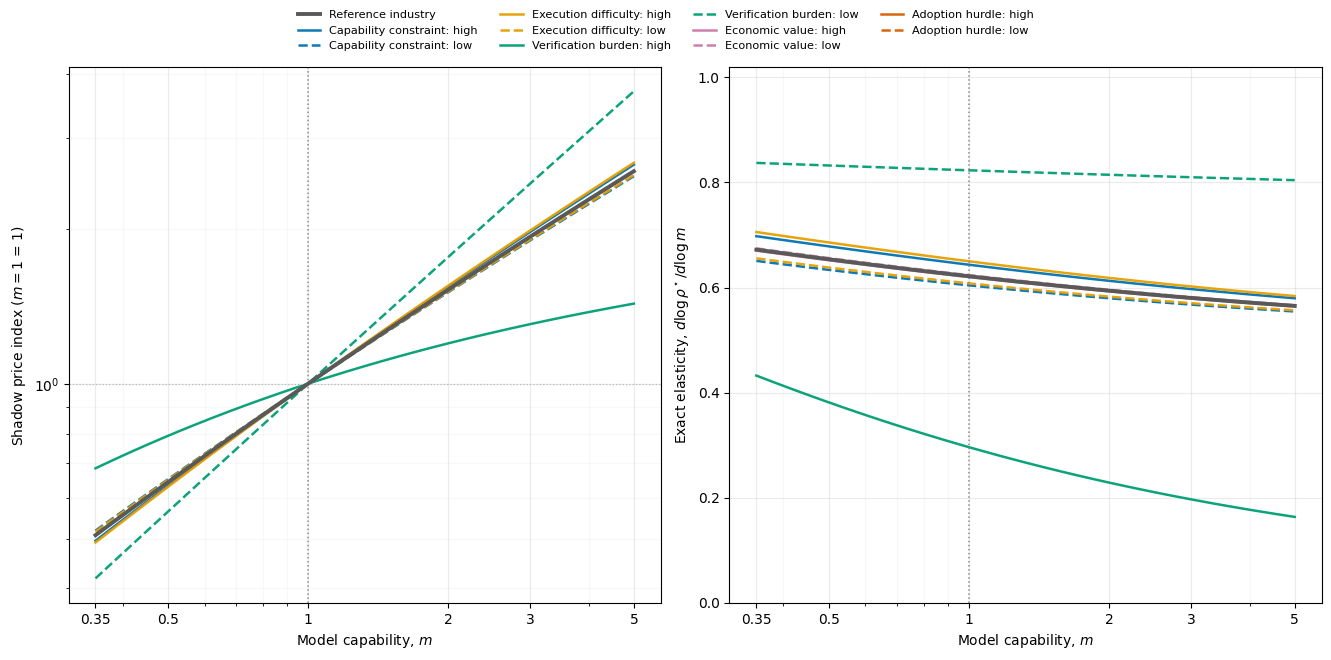

In [9]:
exact_attention_capability_results = {}
for industry in industries:
    model = IndustryModel(industry)
    exact_attention_capability_results[industry.name] = [
        attention_optimizer.solve_interior(
            model, replace(baseline, model_capability=float(capability))
        )
        for capability in model_capabilities
    ]

objective_differences = []
for industry in industries:
    name = industry.name
    for general, scalar in zip(
        attention_capability_results[name], exact_attention_capability_results[name]
    ):
        objective_differences.append(
            abs(general.surplus_per_attention_hour - scalar.surplus_per_attention_hour)
            / (abs(scalar.surplus_per_attention_hour) + industry.human_cost_per_hour)
        )
print(
    "Largest relative difference between general and scalar solutions: "
    f"{max(objective_differences):.2e}"
)

shadow_price_figure = plot_attention_shadow_price(
    model_capabilities,
    exact_attention_capability_results,
    filename="shadow-price-of-attention-vs-capability.png",
)

shadow_rows = []
for industry in industries:
    model = IndustryModel(industry)
    endpoint_outcomes = [
        attention_optimizer.solve_interior(
            model, replace(baseline, model_capability=capability)
        )
        for capability in (0.35, 1.0, 5.0)
    ]
    shadow_prices = [
        outcome.surplus_per_attention_hour + industry.human_cost_per_hour
        for outcome in endpoint_outcomes
    ]
    baseline_outcome = endpoint_outcomes[1]
    s = baseline_outcome.policy.delegation_hours
    variable_review = industry.verification_scale * (
        s ** industry.verification_elasticity
    )
    elasticity = 1.0 - (
        industry.verification_elasticity * variable_review
        / (industry.verification_fixed_hours + variable_review)
    )
    shadow_rows.append(
        f"| {industry.name} | {shadow_prices[0]:,.0f} | "
        f"{shadow_prices[1]:,.0f} | {shadow_prices[2]:,.0f} | "
        f"{elasticity:.3f} |"
    )
shadow_header = (
    "| Parameter case | $\\rho^*(0.35)$ | $\\rho^*(1)$ | "
    "$\\rho^*(5)$ | Elasticity at $m=1$ |\n"
    "|---|---:|---:|---:|---:|\n"
)
display(Markdown(shadow_header + "\n".join(shadow_rows)))


The left panel indexes each shadow-price curve to one at $m=1$, while the right panel reports its exact local elasticity. Indexing removes level differences without changing monotonicity, turning points, percentage changes, or log slopes.

Capability raises the shadow value of attention in every controlled case. Differences in the indexed paths show how a single parameter group changes the return to capability; overlapping paths identify parameters that affect levels but not this comparative-static shape.


The objective-comparison figure now uses only the reference industry so it isolates the behavioral assumption from industry heterogeneity. The solid blue line solves the attention-constrained problem directly. The dashed gray line first maximizes surplus per unit of work and then applies the attention cap. Each is indexed to its own value at $m=1$.

A user maximizing $u_i$ prefers short, highly reliable chunks and economizes on tokens per unit of work. A user maximizing $J_i$ cares about how much net value each scarce verification hour supports. That user can choose longer chunks and greater inference intensity, accepting lower reliability on one chunk when the increase in machine work launched per checkpoint is worthwhile.


### Per-work surplus as capability improves

The next figure retains the per-work optimizer, so $u_i^\star=\max u_i$ keeps its usual meaning and can feed the adoption equation. Each case is indexed to its own surplus at $m=1$ to compare response shapes.


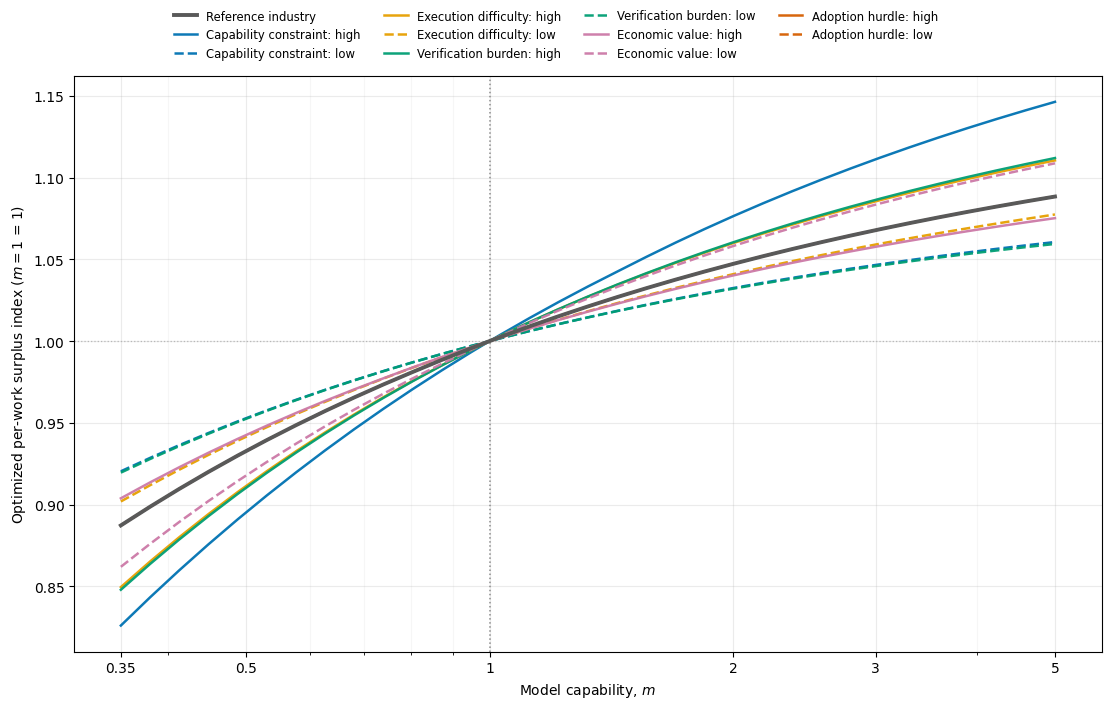

In [10]:
surplus_capability_figure = plot_surplus_by_capability(
    model_capabilities,
    per_work_capability_results,
    filename="optimized-surplus-vs-model-capability.png",
    xticks=TECHNOLOGY_TICKS,
)

### Work-limited token demand and adoption

The next two figures solve the work-limited problem for the reference industry and all ten controlled high/low variants. Each panel holds the other scenario variables at baseline, reoptimizes $(s,x,k)$, and reports $D_i^{\mathrm{work}}=W_iA_ix_i^\star E_i^\star$. Every case uses the same potential work $W_i$.

The first figure reports absolute demand. The second divides each curve by its own demand at the common scenario baseline: $m=1$, $\eta=1$, or a token price of 10 dollars per million. This normalization multiplies a curve by one constant, so it preserves its direction, turning points, percentage changes, and log slope while removing level differences. Gray denotes the reference industry; each parameter group has one color, with solid for its high setting and dashed for its low setting.


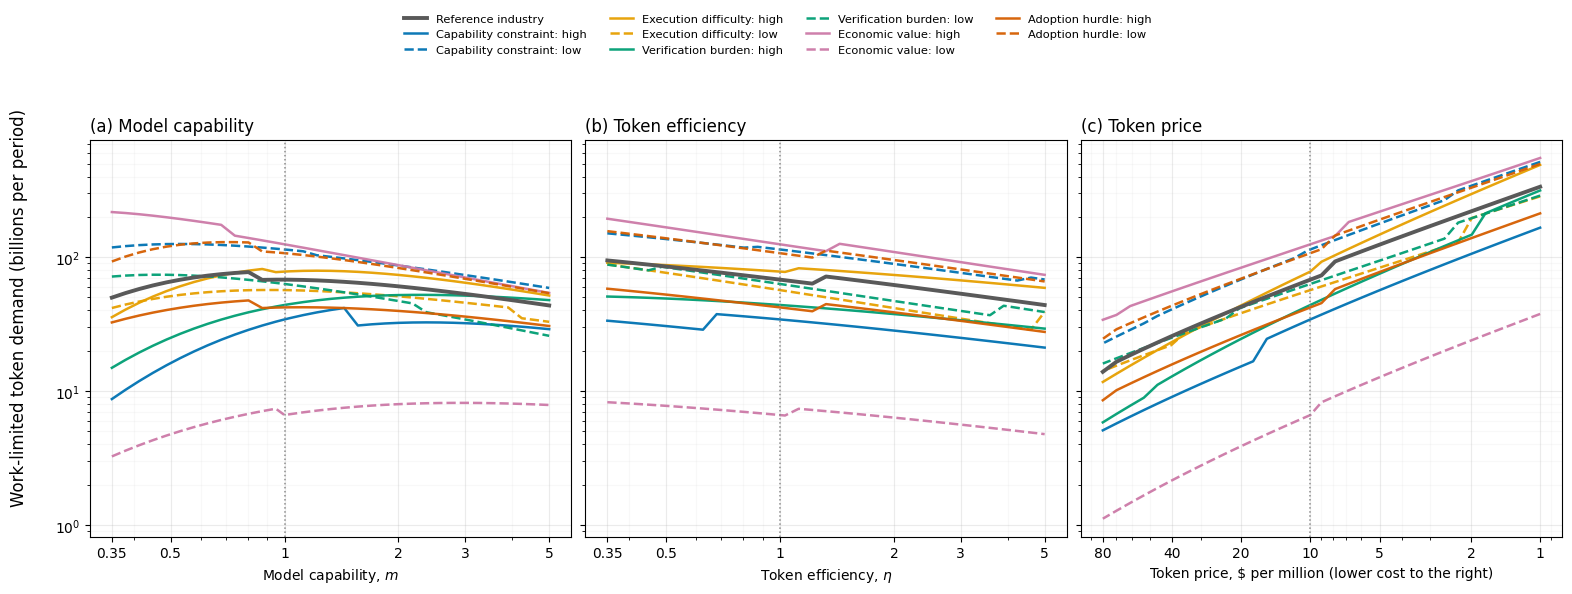

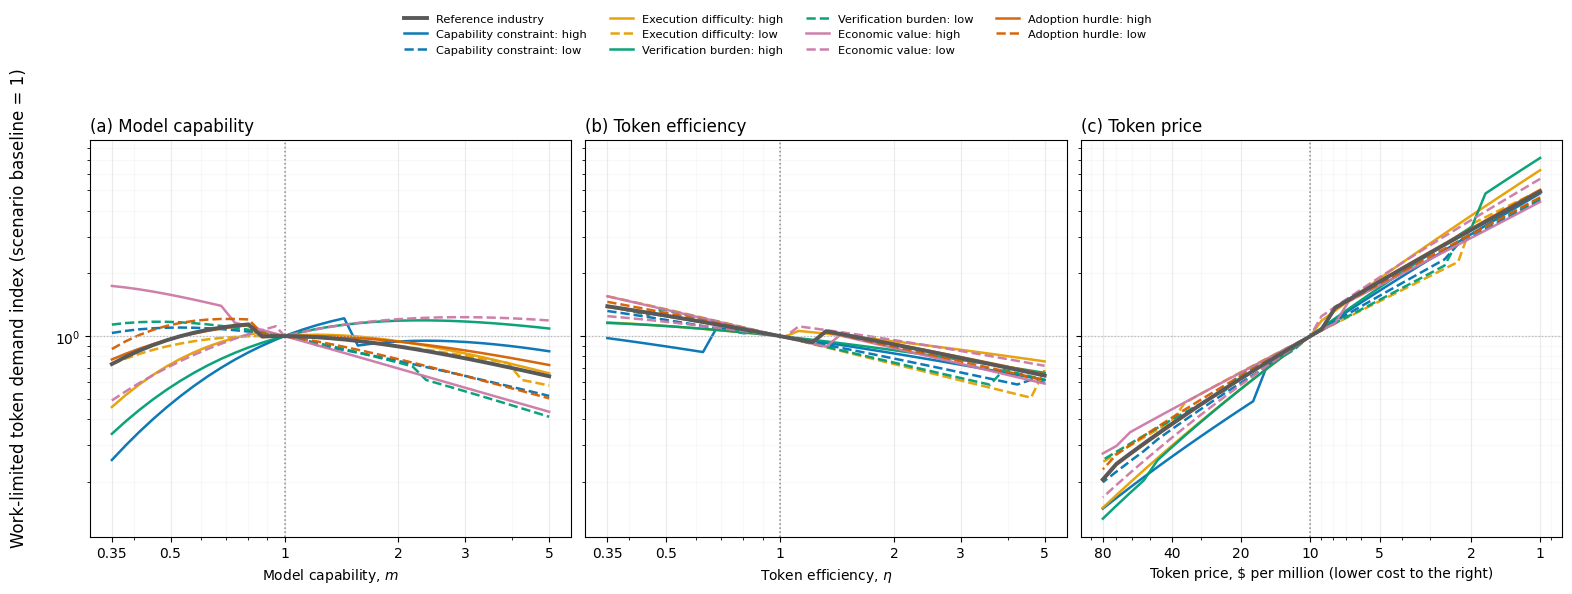

In [11]:
work_limited_levels_figure = plot_demand_panels(
    model_capabilities,
    work_limited_capability_results,
    token_efficiencies,
    work_limited_efficiency_results,
    token_prices,
    work_limited_price_results,
    regime="work",
    normalize=False,
    filename="work-limited-token-demand-levels.png",
)
work_limited_indexed_figure = plot_demand_panels(
    model_capabilities,
    work_limited_capability_results,
    token_efficiencies,
    work_limited_efficiency_results,
    token_prices,
    work_limited_price_results,
    regime="work",
    normalize=True,
    filename="work-limited-token-demand-indexed.png",
)


The level figure answers how much token demand each controlled case produces under the common scale normalization. The indexed figure answers the separate question emphasized here: how does demand change as capability, efficiency, or price moves? Comparing the pair prevents large level differences from hiding economically important curvature.

Work-limited demand combines adoption with tokens per adopted unit. Capability or efficiency can raise optimized surplus and adoption while reducing the token intensity required for existing work. Lower token prices increase optimized token quantity through greater inference intensity and any induced adoption response.


### Attention-limited token demand: levels and indexed changes

These two figures mirror the work-limited comparison across model capability, token efficiency, and token price. They solve the attention-constrained objective directly and report $D_i^H=H_i s_i^H x_i^H/h_i(s_i^H)$, with the same $H_i=100{,}000$ verification hours for every case.

Both regimes use the same eleven cases. The single verification-burden pair changes $(h_{0,i},h_{1,i},\beta_i)$ jointly: high burden requires more review that grows almost proportionally with scope, while low burden requires less review that grows slowly. This changes both demand levels and indexed responses. Adoption-hurdle variants coincide with the reference in both attention-limited figures because adoption does not enter this abundant-work regime.

The level figure compares demand at a given scenario value. The indexed figure divides each curve by its own demand at the scenario baseline, so it compares proportional changes from that baseline rather than demand levels. Gray denotes the reference; solid and dashed lines denote the high and low settings within each color group.


Verification burden: low: demand at m=5 / demand at m=1 = 3.632
Reference industry: demand at m=5 / demand at m=1 = 2.395
Verification burden: high: demand at m=5 / demand at m=1 = 0.892


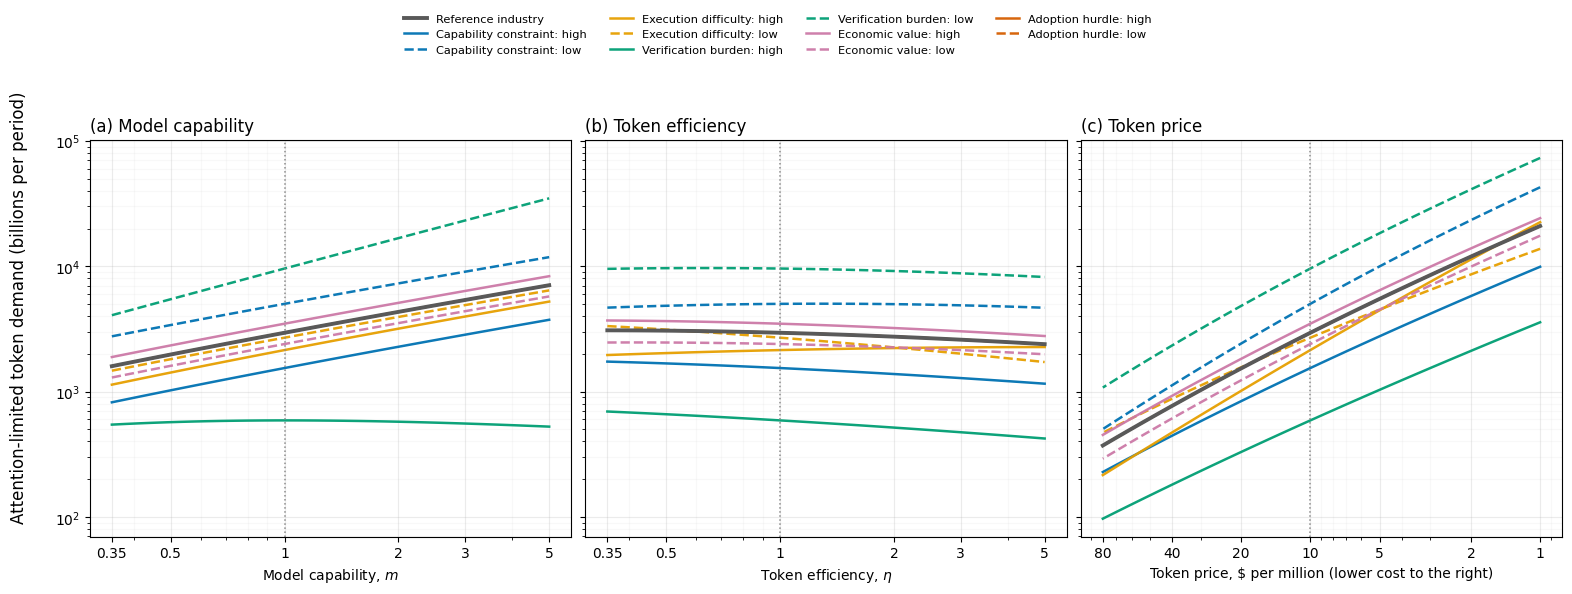

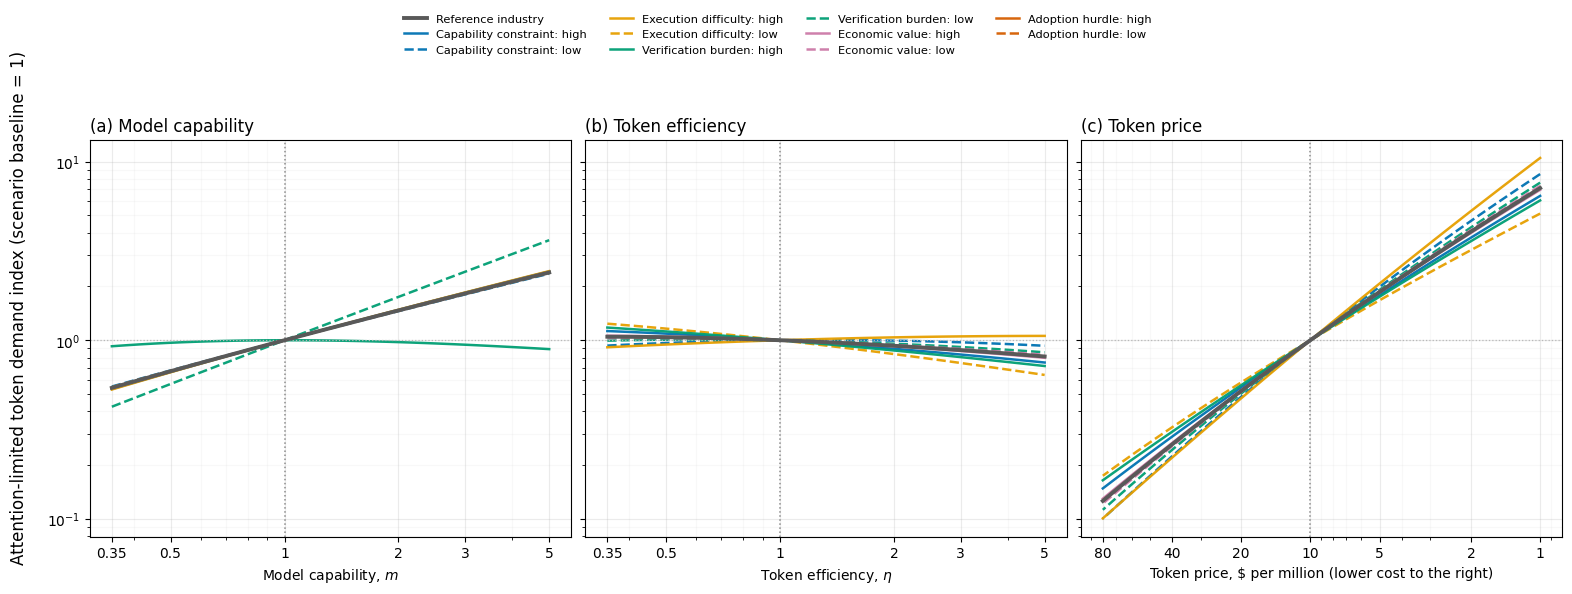

In [12]:
attention_limited_levels_figure = plot_demand_panels(
    model_capabilities,
    attention_capability_results,
    token_efficiencies,
    efficiency_results,
    token_prices,
    price_results,
    regime="attention",
    normalize=False,
    filename="attention-limited-token-demand-levels.png",
)
attention_limited_indexed_figure = plot_demand_panels(
    model_capabilities,
    attention_capability_results,
    token_efficiencies,
    efficiency_results,
    token_prices,
    price_results,
    regime="attention",
    normalize=True,
    filename="attention-limited-token-demand-indexed.png",
)

capability_baseline_index = baseline_index(model_capabilities, 1.0)
for name in (
    "Verification burden: low", "Reference industry", "Verification burden: high"
):
    outcomes = attention_capability_results[name]
    ratio = (
        attention_limited_tokens(outcomes[-1])
        / attention_limited_tokens(outcomes[capability_baseline_index])
    )
    print(f"{name}: demand at m=5 / demand at m=1 = {ratio:.3f}")


When fixed verification overhead is negligible, the model has the scaling form $D_i^H(m)\propto m^{1-\beta_i}$: capability can expand delegated scope roughly in proportion to $m$, while review grows with $s^{\beta_i}$. This is exact when $h_{0,i}=0$ and an unconstrained interior optimum exists. The positive fixed overhead in this calibration makes the relation approximate, and optimal inference intensity can change enough to reverse demand growth when verification is nearly proportional to scope.

The verification-burden comparison combines review-time levels and their growth with scope in one group. It therefore changes both the absolute demand level and the shape of the capability response. It does not separately identify each verification parameter's effect; the uniform-time experiment in manuscript Section 4.4 isolates the pure level effect.


## Retry choice with abundant interchangeable work

The attention-constrained solution chooses $k=1$ throughout these sweeps. This follows from the objective rather than the calibration: at fixed $(s,x)$, $P_k/E_k\leq qr=P_1/E_1$ because $1-(1-r)^k\leq kr$. A failed attempt makes the same task more likely to lie in the unsolvable tail, while a fresh task is another draw from the prior.

Retries can reappear when work is fixed, abandonment destroys value, tasks differ in value, attempts learn from failures, or setup is reusable. The table below verifies the numerical attention-constrained choice for every controlled case.


In [13]:
retry_rows = []
for industry in industries:
    name = industry.name
    price_ks = sorted({item.policy.max_attempts for item in price_results[name]})
    efficiency_ks = sorted({item.policy.max_attempts for item in efficiency_results[name]})
    capability_ks = sorted({item.policy.max_attempts for item in attention_capability_results[name]})
    retry_rows.append(
        f"| {name} | {price_ks} | {efficiency_ks} | {capability_ks} |"
    )
retry_header = (
    "| Parameter case | k across price sweep | k across efficiency sweep | k across capability sweep |\n"
    "|---|---:|---:|---:|\n"
)
display(Markdown(retry_header + "\n".join(retry_rows)))

| Parameter case | k across price sweep | k across efficiency sweep | k across capability sweep |
|---|---:|---:|---:|
| Reference industry | [1] | [1] | [1] |
| Capability constraint: high | [1] | [1] | [1] |
| Capability constraint: low | [1] | [1] | [1] |
| Execution difficulty: high | [1] | [1] | [1] |
| Execution difficulty: low | [1] | [1] | [1] |
| Verification burden: high | [1] | [1] | [1] |
| Verification burden: low | [1] | [1] | [1] |
| Economic value: high | [1] | [1] | [1] |
| Economic value: low | [1] | [1] | [1] |
| Adoption hurdle: high | [1] | [1] | [1] |
| Adoption hurdle: low | [1] | [1] | [1] |

### Optimizer audit

The optimizer searches a log grid and refines multiple starting points for every retry cap. The analytical scalar solver independently checks the interior attention-constrained capability solutions. The automated test suite also verifies the retry result, capability elasticities, and the invariance of the attention policy to a uniform verification-time multiplier.

The primary demand and spending plots assume abundant useful work and 100,000 available human verification hours per controlled case. The work-limited figures instead fix potential work and let adoption respond. The capability-objective comparison uses the reference case alone so that it changes the behavioral objective without simultaneously changing industry parameters.


In [14]:
sweep_sets = {
    "attention price": price_results,
    "attention efficiency": efficiency_results,
    "attention capability": attention_capability_results,
    "work price": work_limited_price_results,
    "work efficiency": work_limited_efficiency_results,
    "work capability": work_limited_capability_results,
}
boundary_hits = []
policy_count = 0
maximum_retry_cap = 0
for sweep_name, results in sweep_sets.items():
    for industry_name, outcomes in results.items():
        for point_index, outcome in enumerate(outcomes):
            policy_count += 1
            policy = outcome.policy
            maximum_retry_cap = max(maximum_retry_cap, policy.max_attempts)
            for variable, value, lower, upper in (
                ("s", policy.delegation_hours,
                 settings.min_delegation_hours, settings.max_delegation_hours),
                ("x", policy.tokens_per_work_hour,
                 settings.min_tokens_per_work_hour, settings.max_tokens_per_work_hour),
            ):
                if np.isclose(value, lower, rtol=1e-5) or np.isclose(value, upper, rtol=1e-5):
                    boundary_hits.append((sweep_name, industry_name, point_index, variable))
            if policy.max_attempts == settings.max_attempts:
                boundary_hits.append((sweep_name, industry_name, point_index, "k"))
            if sweep_name.startswith("attention"):
                assert outcome.surplus_per_attention_hour > 0
            assert np.isfinite(outcome.work_limited_tokens)
            assert outcome.work_limited_tokens > 0
assert not boundary_hits, boundary_hits
assert max(objective_differences) < 1e-8

# Price is increasing in these arrays, so optimized token quantity must not rise.
for results, quantity in (
    (price_results, attention_limited_tokens),
    (work_limited_price_results, lambda item: item.work_limited_tokens),
):
    for industry_name, outcomes in results.items():
        values = np.array([quantity(outcome) for outcome in outcomes])
        assert np.max(np.diff(values)) <= 1e-6 * np.max(values), industry_name

reference_work = per_work_optimizer.solve(IndustryModel(REFERENCE_INDUSTRY), baseline)
print(f"Audited {policy_count} policies; no continuous or retry bounds bind.")
print(f"Largest selected retry cap: {maximum_retry_cap} of {settings.max_attempts} allowed.")
print(f"Reference work-limited adoption at baseline: {reference_work.adoption_share:.2%}.")
print("Price-demand monotonicity and scalar-solver agreement checks passed.")


# Verify that the joint difficulty labels describe the plotted policy range.
# Evaluate each technical bundle at the SAME policy and scenario; comparing
# its own optimized outcomes would confound difficulty with policy responses.
ordering_groups = (
    ("Capability constraint", "capability_share", True),
    ("Execution difficulty", "conditional_success", True),
    ("Verification burden", "verification_hours", False),
)
ordering_models = {
    group: tuple(IndustryModel(comparison_by_name[name]) for name in (
        group + ": low", "Reference industry", group + ": high"
    ))
    for group, _, _ in ordering_groups
}
scenario_axes = (
    ("price", "token_price_per_million", token_prices),
    ("efficiency", "token_efficiency", token_efficiencies),
    ("capability", "model_capability", model_capabilities),
)
ordering_checks = 0
for axis, field, values in scenario_axes:
    for regime in ("work", "attention"):
        for name, outcomes in sweep_sets[f"{regime} {axis}"].items():
            for value, outcome in zip(values, outcomes):
                scenario = replace(baseline, **{field: float(value)})
                for group, method, high_is_lower in ordering_groups:
                    low, ref, high = [
                        getattr(model, method)(outcome.policy, scenario)
                        for model in ordering_models[group]
                    ]
                    if high_is_lower:
                        assert low >= ref >= high, (axis, regime, name, group)
                    else:
                        assert low <= ref <= high, (axis, regime, name, group)
                    ordering_checks += 1

adoption_names = ("Adoption hurdle: low", "Reference industry", "Adoption hurdle: high")
adoption_models = [IndustryModel(comparison_by_name[name]) for name in adoption_names]
adoption_surpluses = []
for axis, _, _ in scenario_axes:
    for name in adoption_names:
        for outcome in sweep_sets[f"work {axis}"][name]:
            u = outcome.surplus_per_work_hour
            low, ref, high = [model.adoption_share(u) for model in adoption_models]
            assert low >= ref >= high, (axis, name, u)
            adoption_surpluses.append(u)
assert all(industry.human_cost_per_hour == 100.0 for industry in industries)
assert [industry.name for industry in industries] == [
    industry.name for industry in work_limited_industries
]
print(f"Difficulty ordering passed {ordering_checks} same-policy checks.")
print(
    f"Adoption ordering passed for surplus {min(adoption_surpluses):.2f} "
    f"to {max(adoption_surpluses):.2f}; all cases hold w fixed."
)


Audited 2244 policies; no continuous or retry bounds bind.
Largest selected retry cap: 7 of 12 allowed.
Reference work-limited adoption at baseline: 50.45%.
Price-demand monotonicity and scalar-solver agreement checks passed.
Difficulty ordering passed 6732 same-policy checks.
Adoption ordering passed for surplus 95.07 to 116.61; all cases hold w fixed.
